# Part A: Perceptual Manifold Sampling (PGA)

This notebook implements **Projected Gradient Ascent (PGA)** sampling for perceptual manifolds.

Goal: generate samples $x$ such that $p(c\mid x) > p_0$ for a target class $c$.

In [1]:
import math
from typing import Optional, Tuple, Dict, Any

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(7)


def infer_model_family(model: nn.Module) -> str:
    """Infer whether we should optimize with Adam (CLIP-like) or SGD (CNN-like)."""
    name = model.__class__.__name__.lower()
    has_clip_traits = hasattr(model, 'encode_image') or ('clip' in name)
    return 'clip' if has_clip_traits else 'cnn'


def _extract_logits(model_output):
    """Normalize model outputs into class logits with shape [B, C]."""
    if isinstance(model_output, tuple):
        return model_output[0]
    if hasattr(model_output, 'logits'):
        return model_output.logits
    return model_output

In [2]:
def sample_perceptual_manifold_pga(
    model: nn.Module,
    class_index: int,
    num_samples: int,
    confidence_threshold: float,
    max_iterations: int = 1000,
    step_size: float = 1e-2,
    input_shape: Tuple[int, int, int] = (3, 32, 32),
    device: Optional[torch.device] = None,
) -> Tuple[torch.Tensor, Dict[str, Any]]:
    """
    Sample points on a model's perceptual manifold using projected gradient ascent.

    Returns:
        samples: Tensor [num_samples, C, H, W] in [0,1]
        stats: dictionary with optimization metadata
    """
    if not (0.0 < confidence_threshold < 1.0):
        raise ValueError('confidence_threshold must be in (0, 1).')

    model.eval()
    model_family = infer_model_family(model)

    if device is None:
        try:
            device = next(model.parameters()).device
        except StopIteration:
            device = torch.device('cpu')

    model = model.to(device)
    c, h, w = input_shape

    accepted = []
    iters_per_sample = []
    final_confidences = []

    for _ in range(num_samples):
        x = torch.rand(1, c, h, w, device=device, requires_grad=True)

        if model_family == 'clip':
            optimizer = torch.optim.Adam([x], lr=step_size)
        else:
            optimizer = torch.optim.SGD([x], lr=step_size, momentum=0.9)

        reached = False
        last_prob = 0.0

        for t in range(1, max_iterations + 1):
            optimizer.zero_grad(set_to_none=True)
            logits = _extract_logits(model(x))

            if logits.ndim != 2:
                raise ValueError('Model output must produce class logits [B, C].')
            if class_index < 0 or class_index >= logits.shape[1]:
                raise ValueError(f'class_index={class_index} invalid for {logits.shape[1]} classes.')

            log_probs = F.log_softmax(logits, dim=1)
            obj = log_probs[:, class_index].mean()

            # Gradient ascent on log p(c|x): maximize objective => minimize -objective
            (-obj).backward()
            optimizer.step()

            with torch.no_grad():
                x.clamp_(0.0, 1.0)
                probs = F.softmax(_extract_logits(model(x)), dim=1)
                p_c = probs[:, class_index].mean().item()
                last_prob = p_c
                if p_c >= confidence_threshold:
                    reached = True
                    accepted.append(x.detach().squeeze(0).cpu())
                    iters_per_sample.append(t)
                    final_confidences.append(p_c)
                    break

        if not reached:
            accepted.append(x.detach().squeeze(0).cpu())
            iters_per_sample.append(max_iterations)
            final_confidences.append(last_prob)

    samples = torch.stack(accepted, dim=0)
    success_count = sum(float(p >= confidence_threshold) for p in final_confidences)

    stats = {
        'model_family': model_family,
        'success_rate': success_count / float(num_samples),
        'mean_iterations': float(sum(iters_per_sample)) / float(num_samples),
        'mean_confidence': float(sum(final_confidences)) / float(num_samples),
        'iters_per_sample': iters_per_sample,
        'final_confidences': final_confidences,
    }

    return samples, stats

In [3]:
# --- Tests with synthetic models so this runs offline and quickly ---
class ToyCNN(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # Two-class logits. Class 0 is favored by larger mean pixel intensity.
        m = x.mean(dim=(1, 2, 3), keepdim=False)
        logits = torch.stack([12.0 * (m - 0.5), -12.0 * (m - 0.5)], dim=1)
        return logits


class MockCLIP(nn.Module):
    def __init__(self):
        super().__init__()

    def encode_image(self, x):
        # Dummy method to trigger CLIP optimizer branch (Adam).
        return x

    def forward(self, x):
        m = x.mean(dim=(1, 2, 3), keepdim=False)
        logits = torch.stack([10.0 * (m - 0.5), -10.0 * (m - 0.5)], dim=1)
        return logits


cnn_model = ToyCNN()
clip_like_model = MockCLIP()

samples_cnn, stats_cnn = sample_perceptual_manifold_pga(
    model=cnn_model,
    class_index=0,
    num_samples=8,
    confidence_threshold=0.9,
    max_iterations=300,
    step_size=0.15,
    input_shape=(3, 32, 32),
)

samples_clip, stats_clip = sample_perceptual_manifold_pga(
    model=clip_like_model,
    class_index=0,
    num_samples=8,
    confidence_threshold=0.8,
    max_iterations=300,
    step_size=0.05,
    input_shape=(3, 32, 32),
)

assert samples_cnn.shape == (8, 3, 32, 32)
assert samples_clip.shape == (8, 3, 32, 32)
assert stats_cnn['model_family'] == 'cnn'
assert stats_clip['model_family'] == 'clip'
assert stats_cnn['success_rate'] > 0.0
assert stats_clip['success_rate'] > 0.0

print('CNN stats:', stats_cnn)
print('CLIP-like stats:', stats_clip)

CNN stats: {'model_family': 'cnn', 'success_rate': 1.0, 'mean_iterations': 35.875, 'mean_confidence': 0.9023250117897987, 'iters_per_sample': [36, 36, 37, 36, 36, 36, 35, 35], 'final_confidences': [0.902804434299469, 0.9030291438102722, 0.9034683704376221, 0.903211772441864, 0.9028956294059753, 0.9024454951286316, 0.9000400304794312, 0.9007052183151245]}
CLIP-like stats: {'model_family': 'clip', 'success_rate': 1.0, 'mean_iterations': 2.0, 'mean_confidence': 0.8651008009910583, 'iters_per_sample': [2, 2, 2, 2, 2, 2, 2, 2], 'final_confidences': [0.8420315384864807, 0.8615661859512329, 0.869446337223053, 0.8830564618110657, 0.8570149540901184, 0.8711448311805725, 0.8738924264907837, 0.8626536726951599]}


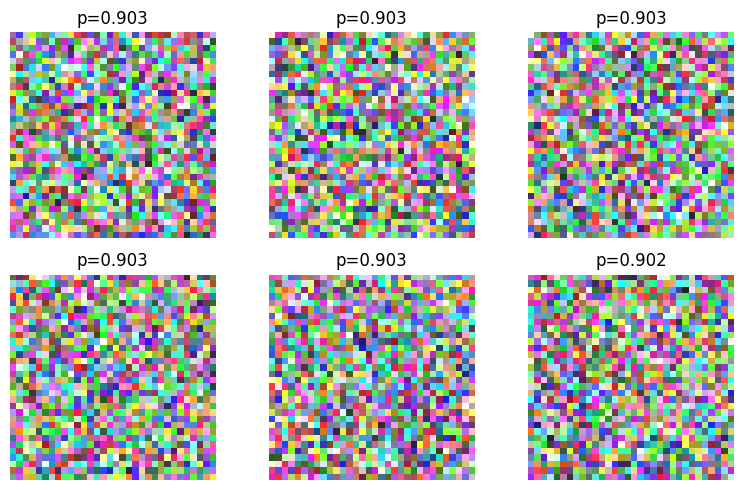

In [4]:
# Visualize a few sampled images (ToyCNN run)
num_show = 6
fig, axes = plt.subplots(2, 3, figsize=(8, 5))
for i, ax in enumerate(axes.flat):
    if i >= num_show:
        ax.axis('off')
        continue
    img = samples_cnn[i].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f'p={stats_cnn["final_confidences"][i]:.3f}')
    ax.axis('off')
plt.tight_layout()
plt.show()